# Naive Bayes

In [7]:
from datetime import datetime
from scipy.sparse import load_npz
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    RocCurveDisplay
)
from sklearn.naive_bayes import MultinomialNB
import pandas as pd

## Carga del dataset

Se cargan los conjuntos de entrenamiento y prueba preprocesados del EDA. En este caso se utilizan únicamente las **características TF-IDF** (vectores de alta dimensionalidad generados por `TfidfVectorizer`).

La variante `MultinomialNB` asume valores no negativos. Dado que los features adicionales generados durante el EDA contienen variables numéricas estandarizadas mediante `StandardScaler` (las cuales introducen valores negativos), se prescinde de ellas para conservar la matriz dispersa TF-IDF original y cumplir estrictamente con las restricciones del modelo.

In [8]:
X_train = load_npz('datasets/X_train.npz')
X_test = load_npz('datasets/X_test.npz')

y_train = pd.read_csv('datasets/y_train.csv')['label']
y_test = pd.read_csv('datasets/y_test.csv')['label']

## Modelo Naive Bayes (MultinomialNB)

Se utiliza la variante `MultinomialNB`, adecuada para problemas de clasificación de texto representados como vectores de frecuencia TF-IDF. 

El algoritmo aplica el teorema de Bayes bajo la suposición de independencia condicional entre las características dada la clase.

Por defecto, se aplica el parámetro de suavizado (`alpha = 1.0`) para evitar probabilidades nulas ante palabras o términos no observados en el conjunto de entrenamiento.

In [9]:
nb_model = MultinomialNB()

start_train_time = datetime.now()
nb_model.fit(X_train, y_train)
end_train_time = datetime.now()

train_duration = end_train_time - start_train_time

start_predict_duration = datetime.now()
y_pred = nb_model.predict(X_test)
end_predict_duration = datetime.now()

predict_duration = end_predict_duration - start_predict_duration

## Evaluación del Modelo

Se evalúa el desempeño del modelo mediante la matriz de confusión y las métricas de clasificación (Exactitud balanceada, Precisión, Sensibilidad/Recall, F1-score y Especificidad). Dado que existe cierto desbalance de clases en el conjunto de datos (aproximadamente 38% de correos corresponden a la clase phishing), se toma la exactitud balanceada como métrica principal de comparación.

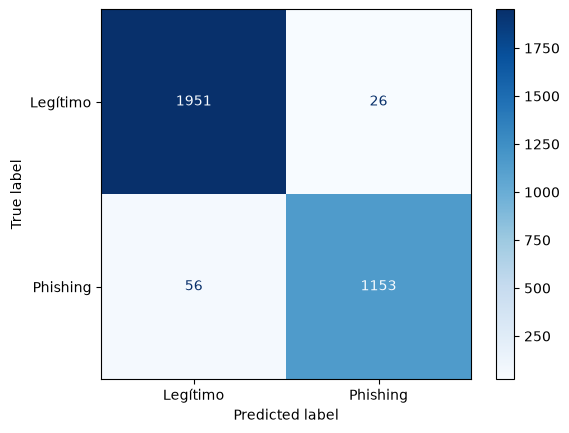

In [10]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['Legítimo', 'Phishing'], cmap='Blues')

In [11]:
cm_nb = confusion_matrix(y_test, y_pred)
P = cm_nb[1, :].sum()
N = cm_nb[0, :].sum()
TP = cm_nb[1, 1]
TN = cm_nb[0, 0]

TPR_nb = TP / P
TNR_nb = TN / N
balanced_accuracy_nb = (TPR_nb + TNR_nb) / 2

precision_nb = precision_score(y_test, y_pred, zero_division=0)
recall_nb = recall_score(y_test, y_pred, zero_division=0)
f1_nb = f1_score(y_test, y_pred, zero_division=0)

print(f"Exactitud balanceada:    {balanced_accuracy_nb:.4f}")
print(f"Precisión:               {precision_nb:.4f}")
print(f"Sensibilidad (Recall):   {TPR_nb:.4f}")
print(f"F1-score:                {f1_nb:.4f}")
print(f"Especificidad:           {TNR_nb:.4f}")
print(f"Recuperación (Recall):   {recall_nb:.4f}")
print(f"Tiempo de entrenamiento: {train_duration}")
print(f"Tiempo de predicción:    {predict_duration}")

Exactitud balanceada:    0.9703
Precisión:               0.9779
Sensibilidad (Recall):   0.9537
F1-score:                0.9657
Especificidad:           0.9868
Recuperación (Recall):   0.9537
Tiempo de entrenamiento: 0:00:00.018137
Tiempo de predicción:    0:00:00.003575


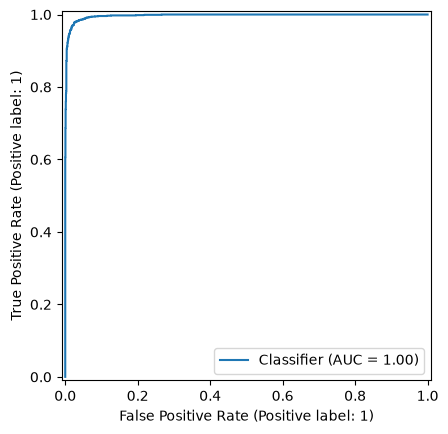

In [12]:
y_scores = nb_model.predict_proba(X_test)[:, 1]

RocCurveDisplay.from_predictions(y_test, y_scores)

## Análisis de Resultados y Conclusiones

El modelo `MultinomialNB` alcanza un rendimiento sobresaliente utilizando únicamente la representación vectorial TF-IDF.

Destaca principalmente su alta especificidad (0.98) y precisión (0.97), lo cual implica una baja tasa de falsos positivos (correos legítimos clasificados erróneamente como phishing).

Muestra tiempos de ejecución extremadamente bajos (~0.018s en entrenamiento y ~0.003s en predicción), ofreciendo una gran relación entre rendimiento predictivo y costo computacional de los modelos evaluados.

A pesar de utilizar únicamente features generados por TF-IDF, la representación léxica demuestra ser altamente discriminativa por sí sola.